# Блок 1

Воспользовавшись [данными](https://www.kaggle.com/datasets/rodolfofigueroa/spotify-12m-songs/code) и удобными для вас библиотеками для рисования/обработки датафреймов ответьте на список вопросов, аргументировав свою позицию.


1. Можно ли по данным датасета спотифай сказать, что музыкальные композиции с 90х годов стали сложнее или проще

2. Коррелирует ли характер тональности с темпом

3. (valence - Measures how positive a track sounds, from 1 to 0) - как коррелирует с характером(мажор/минор) тональности и коррелирует ли

4. Можно ли сказать, что за последнее время ключи тональностей (key) стали менее/более разнообразными

5. Какое совместное влияние оказывают факторы tempo, mode и loudness на показатель valence


In [65]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('tracks_features.csv')

column_names = df.columns.tolist()
column_names

['id',
 'name',
 'album',
 'album_id',
 'artists',
 'artist_ids',
 'track_number',
 'disc_number',
 'explicit',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'duration_ms',
 'time_signature',
 'year',
 'release_date']

In [88]:
df = df.dropna()
df = df[df['year'] > 0]
df = df[df['tempo'] > 0]

# 1. Можно ли по данным датасета спотифай сказать, что музыкальные композиции с 90х годов стали сложнее или проще

В текущем датасете есть следующие параметры, в задаче не указано определение понятия "Сложности композиции", поэтому определим её самостоятельно.
Есть вариант "Технической Сложности" и "Сложности восприятия", кажется, в исследовании предполагалось техническая составляющая.
 - `explicit` - не влияет на сложность музыки, а относится к музыкальным ограничением
 - `danceability` - в большей степени относится к восприятию музыки, не влияет
 - `energy` - этот параметр скорее указывает на "жанр" композиции, чем на её сложность
 - `key` - тональность не влияет на сложность
 - `loudness` - нет влияния на понятие "сложности" композиций
 - `mode` - не влияет на сложность композиции
 - `speechiness` - написание текстов делает процесс создания музыки более сложным, поэтому данный параметр влияет
 - `acousticness` - в большей степени влияет на "жанр" в котором проигрываются композиции
 - `instrumentalness` - чем выше, тем сложнее композиция
 - `liveness` - не влияет на сложность, так как больше про восприятие музыки
 - `valence` - также относится к восприятию музыки
 - `tempo` - чем выше тем, тем сложнее исполнять и сложнее композиция
 - `duration_ms` - чем длиннее запись, тем сложнее будет музыкальная комозиция
 - `time_signature` - музыкальный размер, влияет на сложность, при этом 1/4 и 5/4 считаются более сложными, а 3/4 и 4/4 менее ([ссылка](https://jadebultitude.com/time-signature-5-4/))

Таким образом составим композитную метрику из следующих полей: `speechiness`, `instrumentalness`, `tempo`, `duration_ms`, `time_signature`.
Нормализуем данные:
1. `speechiness` - уже нормализовано, но нужно ограничить сверху, до 0.6 - иначе музыкальная композиция будет состоять исключительно из слов
2. `time_signature` преобразуем в `ts_complexity`
   1. 3/4, 4/4 (значения 3, 4) = 0.5 (умеренная сложность)
   2. 1/4, 2/4 и другие (значения 1, 5) = 1.0 (высокая сложность)
3. `tempo`, `duration_ms` - нормализуем `normalized(x) = (x - x.min()) / (x.max() - x.min())`
4. `instrumentalness` - нормализовано

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('tracks_features.csv')
df['speechiness_capped'] = df['speechiness'].clip(upper=0.6)

def get_time_signature_complexity(ts):
    if ts in [3, 4]:
        return 0.2
    elif ts in [1, 5]:
        return 1.0
    else:
        return 0.5

df['ts_complexity'] = df['time_signature'].apply(get_time_signature_complexity)

complexity_features = ['instrumentalness', 'speechiness_capped', 'tempo', 'duration_ms', 'ts_complexity']

df_complexity_normalized = (df[complexity_features] - df[complexity_features].min()) / (df[complexity_features].max() - df[complexity_features].min())

df['complexity_score'] = df_complexity_normalized.mean(axis=1)

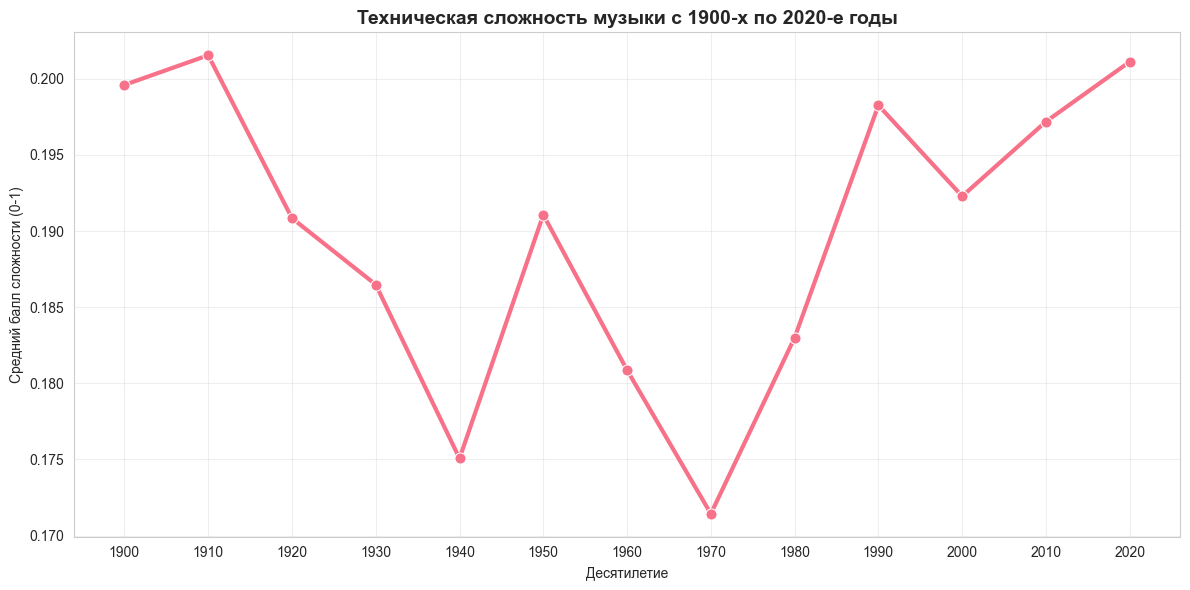

In [95]:
df['decade'] = (df['year'] // 10) * 10
complexity_by_decade = df.groupby('decade')['complexity_score'].mean().reset_index()
complexity_by_decade = complexity_by_decade[complexity_by_decade['decade'] > 0]

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.lineplot(data=complexity_by_decade,
             x='decade',
             y='complexity_score',
             marker='o',
             markersize=8,
             linewidth=3)
plt.title('Техническая сложность музыки с 1900-х по 2020-е годы', fontsize=14, fontweight='bold')
plt.xlabel('Десятилетие')
plt.ylabel('Средний балл сложности (0-1)')
plt.grid(True, alpha=0.3)
plt.xticks(complexity_by_decade['decade'])
plt.tight_layout()
plt.show()

Музыкальные композиции по композитной метрики, состоящей из `['instrumentalness', 'speechiness', 'tempo', 'duration_ms', 'time_signature']` с 90х годов стали немного сложнее

## 2. Коррелирует ли характер тональности с темпом

Коэффициент корреляции Cпирмена между key и tempo: 0.005, 0.000


Text(30.575617283950628, 0.5, 'Темп')

<Figure size 1400x800 with 0 Axes>

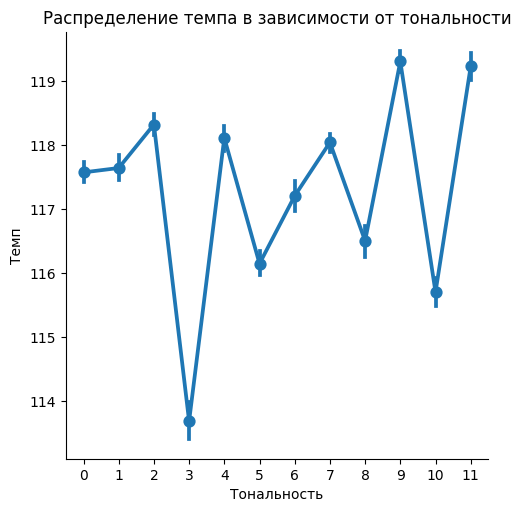

In [6]:
# key, tempo
import seaborn as sns
from scipy.stats import spearmanr

# Высчитываем корреляцию Cпирмена, так как категории имеют порядок
correlation, pvalue = spearmanr(df['key'], df['tempo'])
print(f"Коэффициент корреляции Cпирмена между key и tempo: {correlation:.3f}, {pvalue:.3f}")

# https://seaborn.pydata.org/tutorial/categorical.html#point-plots
plt.figure(figsize=(14, 8))
sns.catplot(data=df, x="key", y="tempo", kind="point")
plt.title('Распределение темпа в зависимости от тональности')
plt.xlabel('Тональность')
plt.ylabel('Темп')

Корреляция Cпирмена равна 0.006, околонулевая корреляция, [очень слабая](https://www.scribbr.com/statistics/correlation-coefficient/)

# 3. Как valence коррелирует с характером(мажор/минор) тональности и коррелирует ли

Построим график, чтобы увидеть распредление, воспользуемся корреляцией pointbiserialr для оценки бинарного категориального признака и числового

Коэффициент корреляции pointbiserialr между valence и mode: 0.03903902883280935, p-value: 0.0


Text(0, 0.5, 'Valence')

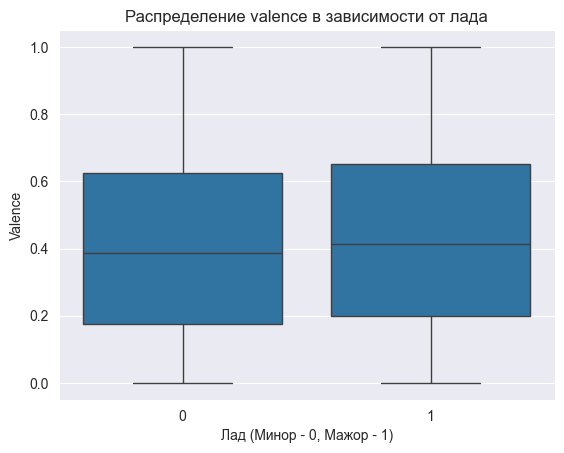

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pointbiserialr.html
correlation, pvalue = stats.pointbiserialr(df["mode"], df["valence"])
print(f"Коэффициент корреляции pointbiserialr между valence и mode: {correlation}, p-value: {pvalue}")

sns.boxplot(data=df, x="mode", y="valence")
plt.title('Распределение valence в зависимости от лада')
plt.xlabel('Лад (Минор - 0, Мажор - 1)')
plt.ylabel('Valence')

# 3. Можно ли сказать, что за последнее время ключи тональностей (key) стали менее/более разнообразными

Чтобы понять, стали ли за последнее время ключ тональностей более иди менее разнообразными нужно посчитать распределения комопзиций по тональностям

Если с годами количество композиций по тональностям становятся более равномерно распределённым, то можно утверждать, что ключи тональности стали более разнообразными. Расчитаем разнообразие по Индексу Шеннона.

In [31]:
# Создаем таблицу сопряженности: годы × тональности
key_year_counts = pd.crosstab(df[df['year'] >= 2000]['year'], df['key'])

# Переходим к долям (процентам)
key_year_percent = key_year_counts.div(key_year_counts.sum(axis=1), axis=0) * 100

Text(0, 0.5, 'Энтропия')

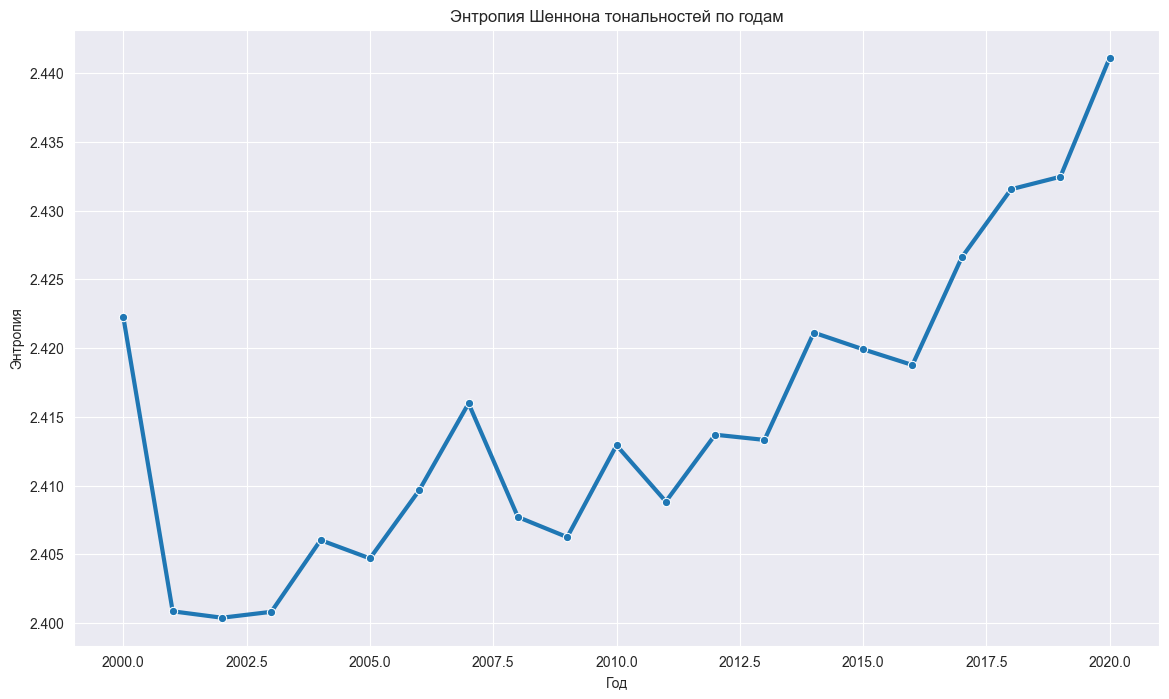

In [48]:
from scipy.stats import entropy

shannon_entropy = key_year_percent.apply(entropy, axis=1)

plt.figure(figsize=(14, 8))
sns.lineplot(x=shannon_entropy.index, y=shannon_entropy.values,
             marker='o', linewidth=3)
plt.title('Энтропия Шеннона тональностей по годам')
plt.xlabel('Год')
plt.ylabel('Энтропия')

Чем выше энтропия, тем больше разнообразие.
Можно наблюдать тренд на увеличение разнообразие за последнее время.

# 5. Какое совместное влияние оказывают факторы tempo, mode и loudness на показатель valence


Чтобы ответить на этот вопрос, нужно выбрать модель для оценки влияния факторов - наиболее часто встречающейся в таких задачах является линейная регрессия


In [60]:
from sklearn.linear_model import LinearRegression

X = df[['tempo','mode','loudness']]
y = df['valence']

model = LinearRegression().fit(X, y)

print("Коэффициенты:", model.coef_)
print("Свободный член:", model.intercept_)
print("R^2:", model.score(X, y))

Коэффициенты: [0.00075261 0.02169463 0.01409286]
Свободный член: 0.49130085486536956
R^2: 0.15669696751358586


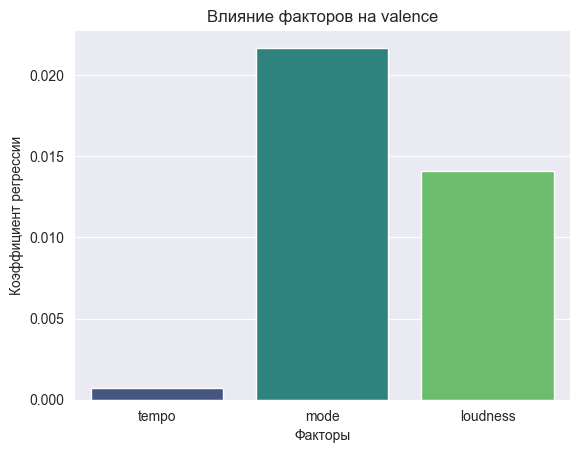

In [72]:
features = ['tempo','mode','loudness']
coefs = model.coef_

sns.barplot(x=features, y=coefs, palette="viridis", hue=features)
plt.title("Влияние факторов на valence")
plt.ylabel("Коэффициент регрессии")
plt.xlabel("Факторы")
plt.show()

## Интерпретируем показатели
1. Все три признака положительно влияют на valence, но эффект каждого небольшой, менее 0.01
2. Модель объясняет ~15,7% вариации valence, это значит, что большая часть вариации valence обусловлена другими факторами, которые не были здесь учтены

# Блок 2

Воспользовавшись данными с сайта о продаже музыкальных инструментов и удобными для вас библиотеками для рисования/обработки датафреймов ответьте на список вопросов, аргументировав свою позицию.


1. Какие факторы влияют на цену инструмента и как?

2. Можно ли разделить объявления на какие-то явно разделяющиеся по некоторому принципу категории: винтаж/ширпотреб/мастеровое и тд

In [265]:
import ast
import pandas as pd

df = pd.read_csv('data/reverb_aggregated.csv')
df = df.dropna()
df = df.join(df['param_dict'].apply(ast.literal_eval).apply(pd.Series))
df = df.drop('param_dict', axis=1)

column_names = df.columns.tolist()
column_names

['title',
 'description',
 'text',
 'price',
 'listing_id',
 'Condition',
 'Brand',
 'Model',
 'Categories',
 'Year',
 'Fretboard Material',
 'Pickup Configuration',
 'Color Family',
 'Right / Left Handed',
 'Body Shape',
 'Number of Strings',
 'Fretboard Radius',
 'Neck Material',
 'Offset Body',
 'Finish Style',
 'Body Type',
 'Body Material',
 'Series',
 'Bridge/Tailpiece Type',
 'Wood Top Style',
 'Nut Width',
 'Model Family',
 'Scale Length',
 'Neck Construction',
 'Number of Frets',
 'Made In',
 'Finish',
 'Product Family',
 'Artist',
 'Frets',
 'Top Material',
 'Finish Features',
 'Model Sub-Family']

# 1.1 Анализ фактор в структурированной информации param_dict

Попробуем для начала воспользоваться структурированной информацией из param_dict и увидеть, какая у нас получится метрика качества линейной регресси.
Если она будет удовлетворительной, то мы сможем объяснить, какие факторы влияют на цену и как.
Распакуем словарь в param_dict и добавим его, как колонкам data_frame.

In [266]:
# преобразуем колонку цен в числовое значение
df['price_num'] = (
    df['price']
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)
    .astype(float)
)

df.to_csv("reverb_aggregated_parsed.csv", index=False, encoding="utf-8")

Возьмём только те признаки, у которых процент пропущенных значений не более 20% и количество уникальных значений в рамках категории не более 60.

In [184]:
valid_cols = [
    c for c in df.columns
    if df[c].isnull().mean() <= 0.20 and df[c].nunique() <= 60
]
valid_cols

['Condition']

Попробуем взять следующие параметры для оценки: `Condition`, `Categories`, `Year`.

Решим задачу линейной регрессии, но перед этим отфильтруем данные.
`Condition` преобразуем в значения от 0 до 8.

In [267]:
df['Condition_clean'] = df['Condition'].str.extract(r'^([^(]+)')[0].str.strip()
condition_map = {
    'Non Functioning': 0,
    'Poor': 1,
    'Fair': 2,
    'Good': 3,
    'Very Good': 4,
    'Excellent': 5,
    'Mint': 6,
    'Brand New': 7
}

df['Condition_num'] = df['Condition_clean'].map(condition_map)

In [268]:
import re
import numpy as np

def parse_year(val):
    if pd.isna(val):
        return np.nan
    s = str(val).lower().strip()

    # Если прямо 4 цифры
    if re.fullmatch(r'\d{4}', s):
        return int(s)

    # Если есть точный год внутри текста
    m = re.search(r'(\d{4})', s)
    if m:
        return int(m.group(1))

    return np.nan

df['Year_clean'] = df['Year'].apply(parse_year)
df = df[df['Year_clean'] >= 1900]

In [269]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

categorical = ['Categories']
numeric = ['Condition_num', 'Year_clean']

# создаём трансформеры с обработкой NaN
numeric_transformer = SimpleImputer(strategy='median')
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', numeric_transformer, numeric),
    ('cat', categorical_transformer, categorical),
])

model = Pipeline([
    ('preprocess', preprocess),
    ('reg', LinearRegression())
])


X = df[categorical + numeric]

y = df['price_num']

model.fit(X, y)
print("R^2:", model.score(X, y))

R^2: 0.06467434331922917


Модель объясняет ~6,4% вариации, можно лишь частично объяснить влияние признаков на цену.

Необходимо найти признаки влияния в неструктурированной информации из поля text.

# 1.2 Анализ факторов в неструктурированной информации text




Воспользуемся TF-IDF - инструментом для извлечения признаков из текстовых данных [ссылка](https://habr.com/ru/companies/otus/articles/755772/)

[L1-регуляризация](https://habr.com/ru/companies/otus/articles/856580/)

In [270]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Lasso

vectorizer = TfidfVectorizer(
    max_features=15000,
    min_df=15,
    ngram_range=(1, 2),
    max_df=0.50,
)

X = vectorizer.fit_transform(df['text'])
y = df['price_num']

model = Lasso(alpha=0.1, max_iter=1000) # используем Lasso для того, чтобы убрать из модели незначительные признаки
model = model.fit(X, y)

print(f"R^2: {model.score(X, y)}")

R^2: 0.8356162879289488


Рассмотрим какие признаки оказывают наибольшее влияние и постараемся из них выделить совокупность факторов, влияющих на цену

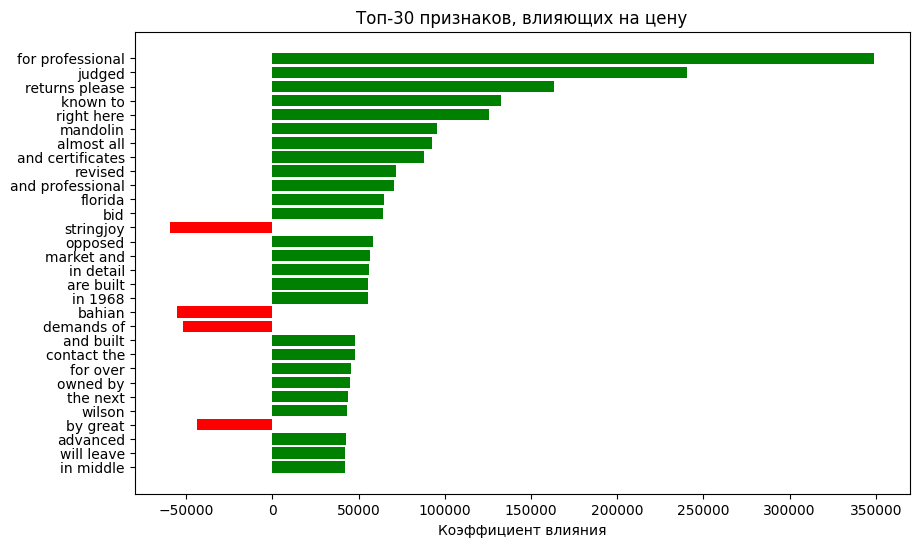

In [271]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Получаем признаки
feature_names = np.array(vectorizer.get_feature_names_out())

coefs = model.coef_

# Складываем в DataFrame
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs
})

# Сортируем по абсолютному значению
top_features = coef_df.reindex(coef_df.coef.abs().sort_values(ascending=False).index)

# Берем топ-30
top30 = top_features.head(30)

# Визуализация
plt.figure(figsize=(10,6))
colors = top30['coef'].apply(lambda x: "green" if x > 0 else "red")
plt.barh(top30['feature'], top30['coef'], color=colors)
plt.xlabel("Коэффициент влияния")
plt.title("Топ-30 признаков, влияющих на цену")
plt.gca().invert_yaxis()
plt.show()

Попробуем по признакам оценить, что влияет на цену:

1. Признаки, указывающие на качество инструмента
   1. `for/and professional` - указывает на то, что инструмент для проффесионалов, что увеличивает его стоимость
   2. `advanced` - продвинутый уровень
   3. `are/and built` - вероятнее всего инструмент сделан из какого-то материала
2. Признаки, связанные с историей, проверкой и уникальностью
   1. `judged` - вероятней всего инструмент был "оценен" экспертами, что добавляет ему ценности
   2. `known to/owned by` - известен благодаря/принадлежавший вероятно какому-то известному музыканту
   3. `and certificates` - сертифицированный инструмент
   4. `revised/copy of` - отрестоврированный инструменты/копия какого-то знаменитого инструмента
3. Бренды и модели
   1. `mandolin` - указание на тип инструмента, результат показывает, что цена увеличивается
   2. `wilson` - [премиальный бренд](https://wilson-hifi.eu/about-us/), увеличивает стоимость продукции
   3. `stringjoy` - бренд, продающий струны, а не музыкальны инструменты, поэтому и итоговая цена меньше
   4. `in 1968` - указывает на то, что инструмент 68-го года выпуска, то есть может считаться раритетом
4. Описательные фразы
   1. `returns please` - в описании указана возможность возврата
   2. `in detail` - подробное описание товара, что свидетельствует о повышение ценового сегмента инструмента
   3. `bid` - указывает на торг/аукцион
   4. `almost all` - свидетельствует об универсальности инструмент, что повышает его цену

Остальным признакам не удалось найти интерпретацию

## Заключение

Таким образом, на цену инструмента влияет сегмент - профессиональный/бюджетный(в том числе косвенные признаки в виде брендов, редких инструментов), год изготовления, сертифицированность/оценка экспертами/реставрация/известность/универсальность, состояние, а также описание инструмента(детализированное) и условия покупки (возвратный).

# 2. Можно ли разделить объявления на какие-то явно разделяющиеся по некоторому принципу категории: винтаж/ширпотреб/мастеровое и тд

Да, объявления можно разделить на категории по типу: винтаж/ширпотреб/мастеровое

На это указывают те признаки, которые были получены из ключевых слов и которые имели прямое влияние на цену:
1. Винтаж - к нему относится год выпуска из отдельной колонке, год в описании `in 1968`, реставрация `revised/copy of`, изсветсный владелец `known to/owned by`, `bid`
2. Мастеровое - на эту категории указывают признаки с указанием для кого инструмент `for/and professional`, `advanced`, с указанием проффесионального бренда `wilson`, `judged`, `certificates`, `almost all`,
3. Ширпотреб - под этот сегмент попадают все остальные товары

In [282]:
import pandas as pd
import re

df = pd.read_csv('data/reverb_aggregated.csv')
df = df.dropna()

# Создаем словари ключевых слов для каждой категории
category_keywords = {
    'vintage_collectible': [
        'in 1968', 'in 1970', 'in 1992', '1960s', '1970s', '1980s', '1990s',
        'vintage', 'old', 'rare', 'collector', 'antique',
        'discontinued', 'historical', 'era', 'bid' 'owned by',
        'previously owned', 'ex-owned', 'luthier', 'custom', 'handmade',
        'handcrafted', 'made by', 'artisan', 'boutique', 'one of a kind',
        'unique', 'signed', 'author'
    ],

    'professional': [
        'professional', 'pro', 'advanced', 'high-end', 'premium', 'flagship',
        'studio grade', 'stage', 'touring', 'session', 'built', 'well-built',
        'quality', 'excellent condition', 'mint condition', 'detail',
        'build', 'judged', 'certificate', 'certified', 'master'
    ],

    'budget_mass_market': [
        'beginner', 'starter', 'economy', 'budget', 'affordable', 'cheap',
        'value', 'entry-level', 'student', 'practice', 'basic', 'standard'
    ]
}

def categorize_by_keywords(text):
    text_lower = text.lower()
    categories_found = []

    for category, keywords in category_keywords.items():
        flag = False
        for keyword in keywords:
            if re.search(r'\b' + re.escape(keyword) + r'\b', text_lower):
                categories_found.append(category)
                flag = True
                break
        if flag:
            break
    return categories_found if categories_found else ['budget_mass_market']

df['price_num'] = (
    df['price']
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)
    .astype(float)
)
df['categories_keywords'] = df['text'].apply(categorize_by_keywords)

df_exploded = df.explode('categories_keywords')

category_stats = df_exploded['categories_keywords'].value_counts()
print("Распределение категорий (метод ключевых слов):")
print(category_stats)

price_by_category = df_exploded.groupby('categories_keywords')['price_num'].agg(['mean', 'count', 'std'])
print("\nСредние цены по категориям:")
print(price_by_category.round(2))

Распределение категорий (метод ключевых слов):
categories_keywords
vintage_collectible    18044
budget_mass_market      9402
professional            4474
Name: count, dtype: int64

Средние цены по категориям:
                        mean  count      std
categories_keywords                         
budget_mass_market   1913.02   9402  3283.21
professional         2034.52   4474  3089.70
vintage_collectible  3101.62  18044  6697.97


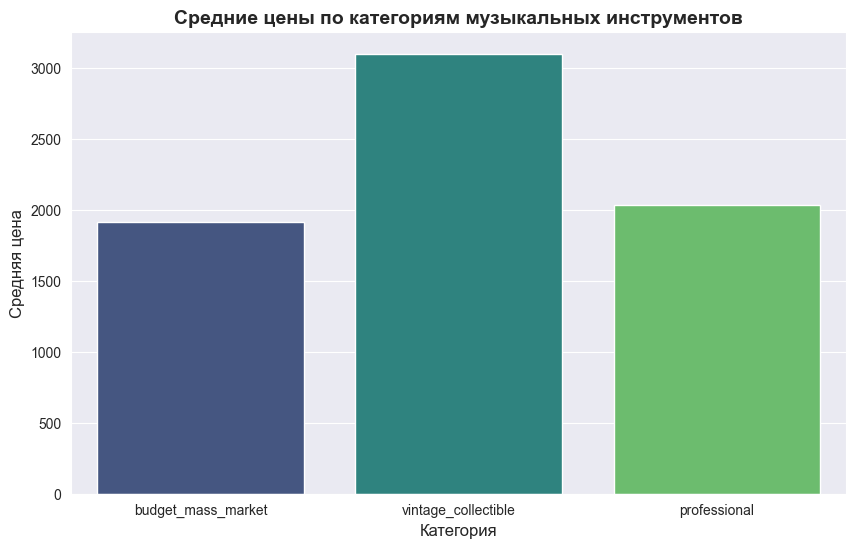

In [283]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_exploded, x='categories_keywords', y='price_num',
            estimator='mean', errorbar=None, palette='viridis', hue='categories_keywords')

plt.title('Средние цены по категориям музыкальных инструментов', fontsize=14, fontweight='bold')
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Средняя цена', fontsize=12)
plt.show()